### Импорты

In [1]:
import faiss

In [2]:
from surprise import Dataset, Reader, KNNBasic, KNNWithMeans, KNNWithZScore, SVD, SVDpp, NMF, CoClustering
from surprise.model_selection import cross_validate, GridSearchCV
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from IPython.display import clear_output

from sentence_transformers import SentenceTransformer

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random

### Обработка и анализ датасета

#### Датасет SpotifyFeatures


In [3]:
df = pd.read_csv('amazon.csv')

# Проверим на пропуски
df.isna().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [4]:
# Избавимся от единственного пропущенного значения
df.dropna(inplace = True)
df.isna().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [7]:
display(df.head())
df.info()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


<class 'pandas.core.frame.DataFrame'>
Index: 1463 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1463 non-null   object
 1   product_name         1463 non-null   object
 2   category             1463 non-null   object
 3   discounted_price     1463 non-null   object
 4   actual_price         1463 non-null   object
 5   discount_percentage  1463 non-null   object
 6   rating               1463 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1463 non-null   object
 9   user_id              1463 non-null   object
 10  user_name            1463 non-null   object
 11  review_id            1463 non-null   object
 12  review_title         1463 non-null   object
 13  review_content       1463 non-null   object
 14  img_link             1463 non-null   object
 15  product_link         1463 non-null   object
dtypes: object(1

In [8]:
df = df[~df['discounted_price'].str.contains(r'\.')]

In [9]:
df['rating'].unique()

array(['4.2', '4.0', '3.9', '4.3', '4.4', '4.1', '4.5', '3.7', '3.3',
       '3.6', '3.4', '3.8', '3.5', '4.6', '3.2', '5.0', '4.7', '3.0',
       '2.8', '4', '3.1', '4.8', '2.3', '|', '2', '3', '2.6', '2.9'],
      dtype=object)

In [10]:
df = df[df['rating'] != '|']
df['rating'].unique()

array(['4.2', '4.0', '3.9', '4.3', '4.4', '4.1', '4.5', '3.7', '3.3',
       '3.6', '3.4', '3.8', '3.5', '4.6', '3.2', '5.0', '4.7', '3.0',
       '2.8', '4', '3.1', '4.8', '2.3', '2', '3', '2.6', '2.9'],
      dtype=object)

In [11]:
df_ratings = df[['product_id', 'user_id', 'rating']]

display(df_ratings.head())

df_ratings.info()

,product_id,user_id,rating
0,B07JW9H4J1,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...",4.2
1,B098NS6PVG,"AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...",4.0
2,B096MSW6CT,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...",3.9
3,B08HDJ86NZ,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...",4.2
4,B08CF3B7N1,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...",4.2


<class 'pandas.core.frame.DataFrame'>
Index: 1448 entries, 0 to 1464
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   product_id  1448 non-null   object
 1   user_id     1448 non-null   object
 2   rating      1448 non-null   object
dtypes: object(3)
memory usage: 45.2+ KB


In [12]:
# Энкодеры
user_encoder = LabelEncoder()
product_encoder = LabelEncoder()

# Преобразование user_id и product_id 
df_ratings["user_id"] = user_encoder.fit_transform(df_ratings["user_id"].copy())
df_ratings["product_id"] = product_encoder.fit_transform(df_ratings["product_id"].copy())

print(df_ratings.head())

   product_id  user_id rating
0         343      618    4.2
1         840       86    4.0
2         812      841    3.9
3         638      252    4.2
4         583       17    4.2


/var/folders/1j/ym432ghd51b826sr2qq1n3k80000gn/T/ipykernel_30518/1368877493.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ratings["user_id"] = user_encoder.fit_transform(df_ratings["user_id"].copy())
/var/folders/1j/ym432ghd51b826sr2qq1n3k80000gn/T/ipykernel_30518/1368877493.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ratings["product_id"] = product_encoder.fit_transform(df_ratings["product_id"].copy())


In [13]:
df_ratings['rating'] = df_ratings['rating'].astype(float)

/var/folders/1j/ym432ghd51b826sr2qq1n3k80000gn/T/ipykernel_30518/4117131181.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ratings['rating'] = df_ratings['rating'].astype(float)


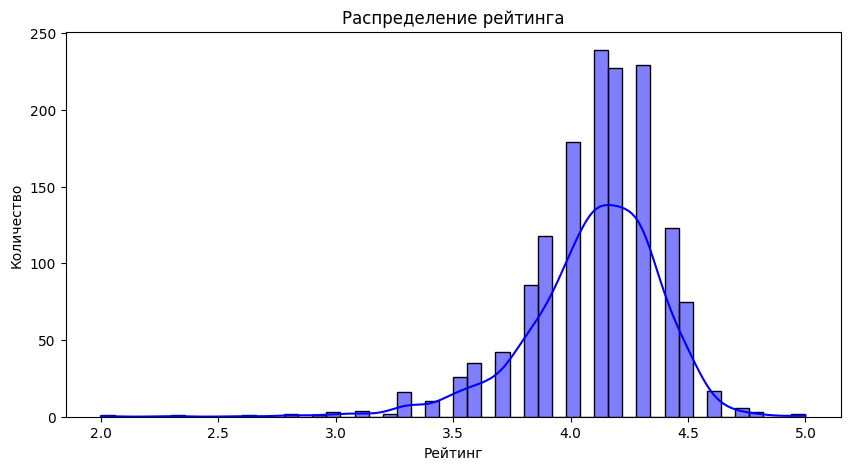

In [14]:
# Визуализация распределения рейтингов
plt.figure(figsize=(10, 5))
sns.histplot(df_ratings["rating"], bins=50, kde=True, color="blue")
plt.title("Распределение рейтинга")
plt.xlabel("Рейтинг")
plt.ylabel("Количество")
plt.show()

In [15]:
df_ratings.groupby('rating').count()

,product_id,user_id
rating,,
2.0,1,1
2.3,1,1
2.6,1,1
2.8,2,2
2.9,1,1
3.0,3,3
3.1,4,4
3.2,2,2
3.3,16,16


In [16]:
df['category'] = df['category'].apply(lambda x: x.split('|')[-1])
df['product_name'] = df['product_name'].apply(lambda x: ' '.join(x.split()[:2]))

In [17]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon,USBCables,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable,USBCables,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast,USBCables,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce,USBCables,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect,USBCables,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [18]:
df_products = df[['product_name', 'category']].copy()
df_products['product_id'] = df_ratings['product_id'].copy()

In [19]:
df['discounted_price'] = df['discounted_price'].apply(lambda x: ''.join(list(x)[1:]).replace(',', '.')).astype(float)
df_products['price'] = df['discounted_price'].copy()

### Создание рекомендательной системы

In [20]:
train_ratings, test_ratings = train_test_split(df_ratings, test_size=0.2, shuffle=True, random_state=37)

In [21]:
reader = Reader(rating_scale=(1, 10))

train_data = Dataset.load_from_df(train_ratings, reader)
test_data = Dataset.load_from_df(test_ratings, reader)

#### Алгоритм KNN (user-based фильтрация и item-based фильтрация)

##### KNNBasic

In [22]:
params = {
    'k': [2, 4, 6, 8, 10],
    'min_k': [1, 2, 3, 4, 5],
}

grid_search = GridSearchCV(KNNBasic, param_grid=params, measures=['mae'])
grid_search.fit(train_data)

clear_output()

In [23]:
print(grid_search.best_params['mae'])

{'k': 2, 'min_k': 1}


In [24]:
cross_validate(KNNBasic(k=2, min_k=2, sim_options={'user_based': True}), test_data, measures=['mae'], cv=5, verbose=True)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     0.2187  0.1986  0.2370  0.1822  0.2248  0.2122  0.0195  
Fit time          0.00    0.00    0.00    0.00    0.00    0.00    0.00    
Test time         0.00    0.00    0.00    0.00    0.00    0.00    0.00    


{'test_mae': array([0.21872771, 0.19858799, 0.23696492, 0.18216409, 0.22476219]),
 'fit_time': (0.0006601810455322266,
  0.00013113021850585938,
  8.797645568847656e-05,
  8.082389831542969e-05,
  9.298324584960938e-05),
 'test_time': (0.0003829002380371094,
  0.00024390220642089844,
  0.0002219676971435547,
  0.0002219676971435547,
  0.0002307891845703125)}

In [25]:
cross_validate(KNNBasic(k=2, min_k=2, sim_options={'user_based': False}), test_data, measures=['mae'], cv=5, verbose=True)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     0.1847  0.2673  0.1966  0.2014  0.2109  0.2122  0.0288  
Fit time          0.00    0.00    0.00    0.00    0.00    0.00    0.00    
Test time         0.00    0.00    0.00    0.00    0.00    0.00    0.00    


{'test_mae': array([0.18466112, 0.26730083, 0.19661118, 0.20138228, 0.2108799 ]),
 'fit_time': (0.00042319297790527344,
  0.00024008750915527344,
  0.0001289844512939453,
  8.511543273925781e-05,
  8.177757263183594e-05),
 'test_time': (0.00025391578674316406,
  0.00027298927307128906,
  0.0002410411834716797,
  0.0002238750457763672,
  0.00021886825561523438)}

In [26]:
print(grid_search.best_params['mae'])

{'k': 2, 'min_k': 1}


In [27]:
cross_validate(KNNWithZScore(k=2, min_k=3, sim_options={'user_based': True}), test_data, measures=['mae'], cv=5, verbose=True)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating MAE of algorithm KNNWithZScore on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     0.2554  0.1923  0.2210  0.2008  0.1762  0.2091  0.0273  
Fit time          0.00    0.00    0.00    0.00    0.00    0.00    0.00    
Test time         0.00    0.00    0.00    0.00    0.00    0.00    0.00    


{'test_mae': array([0.25536564, 0.19233799, 0.22098692, 0.20078032, 0.17618906]),
 'fit_time': (0.0048449039459228516,
  0.00465083122253418,
  0.00417017936706543,
  0.004152059555053711,
  0.004117012023925781),
 'test_time': (0.0004601478576660156,
  0.0002732276916503906,
  0.00021195411682128906,
  0.0002357959747314453,
  0.00022077560424804688)}

#### Алгоритм SVD (не опирается на методы user-based и item-based фильтрации)

##### Classic SVD

In [28]:
params = {
    'n_factors': [25, 50, 100],
    'n_epochs': [5, 7, 10],
    'lr_all': [0.005],
    'reg_all': [0.002],
}

grid_search = GridSearchCV(SVD, param_grid=params, measures=['mae'])
grid_search.fit(train_data)

clear_output()

In [29]:
print(grid_search.best_params['mae'])

{'n_factors': 50, 'n_epochs': 10, 'lr_all': 0.005, 'reg_all': 0.002}


In [31]:
cross_validate(grid_search.best_estimator['mae'], test_data, measures=['mae'], cv=5, verbose=True)

Evaluating MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     0.2145  0.2222  0.1796  0.2540  0.2000  0.2141  0.0247  
Fit time          0.00    0.00    0.00    0.00    0.00    0.00    0.00    
Test time         0.00    0.00    0.00    0.00    0.00    0.00    0.00    


{'test_mae': array([0.21448667, 0.22223543, 0.17956354, 0.25402775, 0.200005  ]),
 'fit_time': (0.0041048526763916016,
  0.0031747817993164062,
  0.0026650428771972656,
  0.0017707347869873047,
  0.0016651153564453125),
 'test_time': (0.0006821155548095703,
  0.0005261898040771484,
  0.0005288124084472656,
  0.0002999305725097656,
  0.0002911090850830078)}

##### SVDpp

In [32]:
params = {
    'n_cltr_u': [10, 13, 16],
    'n_cltr_i': [10, 13, 16],
    'n_epochs': [30, 40, 50],
}

grid_search = GridSearchCV(CoClustering, param_grid=params, measures=['mae'])
grid_search.fit(train_data)

clear_output()

In [33]:
print(grid_search.best_params['mae'])

{'n_cltr_u': 10, 'n_cltr_i': 10, 'n_epochs': 40}


In [34]:
cross_validate(grid_search.best_estimator['mae'], test_data, measures=['mae'], cv=5, verbose=True)

Evaluating MAE of algorithm CoClustering on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     0.2089  0.2169  0.2085  0.2400  0.1838  0.2116  0.0180  
Fit time          0.04    0.04    0.04    0.04    0.04    0.04    0.00    
Test time         0.00    0.00    0.00    0.00    0.00    0.00    0.00    


{'test_mae': array([0.20888823, 0.21688466, 0.2085465 , 0.24001189, 0.18380648]),
 'fit_time': (0.0390470027923584,
  0.03797006607055664,
  0.035652875900268555,
  0.03562188148498535,
  0.035466909408569336),
 'test_time': (0.00021004676818847656,
  0.00017499923706054688,
  0.00015211105346679688,
  0.0001430511474609375,
  0.00015115737915039062)}

In [35]:
# Сравнение результатов всех моделей
results = {
    'KNN User-Based': cross_validate(KNNBasic(k=2, min_k=2, sim_options={'user_based': True}), test_data, measures=['mae'], cv=5, verbose=True)['test_mae'].mean(),
    'KNN Item-Based': cross_validate(KNNBasic(k=2, min_k=2, sim_options={'user_based': False}), test_data, measures=['mae'], cv=5, verbose=True)['test_mae'].mean(),
    'SVD': cross_validate(grid_search.best_estimator['mae'], test_data, measures=['mae'], cv=5, verbose=True)['test_mae'].mean(),
    'SVD++ (CoClustering)': cross_validate(grid_search.best_estimator['mae'], test_data, measures=['mae'], cv=5, verbose=True)['test_mae'].mean()
}

best_model = min(results, key=results.get)
print(f"Лучшая модель: {best_model} с MAE = {results[best_model]}")

# Выводы
print("Выводы:")
print("- KNN показывает схожие результаты для user-based и item-based подходов")
print("- SVD++ (реализованный через CoClustering) показал лучший результат")
print("- Разница между лучшей и худшей моделью небольшая")

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     0.2074  0.1664  0.2098  0.2345  0.2399  0.2116  0.0260  
Fit time          0.00    0.00    0.00    0.00    0.00    0.00    0.00    
Test time         0.01    0.00    0.00    0.00    0.00    0.00    0.00    
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarit